# <font color=#DC143C>Amplitude of zeroth-order disjoint Bogoliubov diagrams contributing to $\boldsymbol{\Pi}_{acdb}$</font>

 ## <font color=#FA8072>Conventions</font>

<p align="justify"> The fully-contracted term(s) processed henceforth correspond to fully-contracted  disjoint Bogoliubov contribution(s) generated by the application of Wick's theorem to the following matrix element (cf. expansion formula of Gorkov's polarization propagator),</p>

$\Pi_{acdb}^{g_1g_3g_4g_2}\lvert_{\mathrm{zeroth~order}}\equiv -i \langle \Phi_0 \lvert T\{{A_{I}}_a^{g_1}(t){A_{I}}_b^{g_2}(t'){A_{I}}_d^{\dagger g_4}(t') {A_{I}}_c^{\dagger g_3}(t)\}\lvert\Phi_0\rangle_{\mathrm{conn}}$

<p align="justify"> The single-particle indices in the expression for $\Pi_{acdb}^{g_1g_3g_4g_2}$ are encoded by integers, then converted into alphabetic format only in the printed analytical expressions.  The index conversion map is provided by</p>

<table>
    <tr>
        <th> a </th> 
        <th> b </th>
        <th> d </th>
        <th> c </th>
    </tr>
        <tr>
        <th> 1 </th> 
        <th> 2 </th>
        <th> 3 </th>
        <th> 4 </th>
    </tr>
    <tr>
        <td> t </td> 
        <td> t' </td>
        <td> t' </td>
        <td> t </td>
    </tr>
    <tr>
        <th> 2 </th> 
        <th> 1 </th>
        <th> 1 </th>
        <th> 2 </th>
    </tr>
</table>

Single-particle indices 'd' and 'b' in Bogoliubov diagrams are involute. For their numeric counterpart, the following convention is adopted:
<center>
    Index $> 0$ $\Rightarrow$ <i>standard</i> <br>
    Index $< 0$ $\Rightarrow$ <i>involute</i>.
</center>

## <font color=#FA8072>Input sequences of single-particle indices</font>

<p align="justify">Loading of the input sequences of single particle indices, corresponding to zeroth order Feynman diagrams of disjoint Bogoliubov type.</p>

In [1]:
Clear[k];

In [2]:
CombBog = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}]; 
 
CombBog[[1]] = {{1, 2}, {3, 4}};

In [5]:
GGFMult = Table[0, {i, 1, 1}]; 

GGFMult[[1]] = 1;

## <font color=#FA8072>Gorkov's Polarization Propagator</font>

### <font color=#E9967A>Definition of the Nambu component</font>

<p align="justify">Four Nambu indices specify univocally each of the 16 Nambu components of the polarization propagator. Normal (anomalous) components possess an even (even or odd) number of '1' and '2' indices. In total, there are 6 normal (indices 1-6 of GPPNambu) and 10 anomalous components (indices 7-16 of GPPNambu). The Nambu component of $\boldsymbol{\Pi}$ is specified by the value of 'NppIdx'.</p>

In [7]:
GPPNambu = Table[0, {i, 1, 16}, {j, 1, 4}]; 

GPPNambu = {{1, 1, 1, 1}, {1, 2, 1, 2}, {2, 1, 2, 1}, {2, 1, 1, 2}, {1, 2, 2, 1}, {2, 2, 2, 2},  {2, 2, 1, 1}, {1, 1, 2, 2}, {2, 1, 1, 1}, {1, 2, 1, 1}, {1,1, 2, 1}, {1, 1, 1, 2}, {1, 2, 2, 2}, {2, 1, 2, 2}, {2, 2, 1, 2}, {2, 2, 2, 1}};

NppIdx = 1;

### <font color=#E9967A>Definition of the auxiliary arrays</font>

Arrays specifying the Nambu indices (cf. 'NambuBog'), the operator type (cf.'SQTypeBog') and distinguishing internal from external single-particle indices (cf. 'IntExtBog') are defined, in accordance with the conventions for the second-quantization operators in the header of the notebook. In particular, to external (internal) single-particle indices the value of '1' ('0') is assigned, whereas for second-quantization operators of creation (annihilation) type the associated array entry is '0' ('1'). For Nambu indices, the convention is straightforward.

In [10]:
SignFlipBog = Table[0, {i, 1, 1}, {j, 1, 2}]; (* option valid only for Bogoliubov diagrams, default value is zero = no sign flip *)

In [11]:
NambuBog = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}];
For[r = 1, r <= 1, r++, 
   For[j = 1, j <= 2, j++, 
     For[k = 1, k <= 2, k++, 
       If[CombBog[[r, j, k]] == 1, NambuBog[[r, j, k]] = GPPNambu[[NppIdx, 1]]]; 
       If[CombBog[[r, j, k]] == 2, NambuBog[[r, j, k]] = GPPNambu[[NppIdx, 4]]]; 
       If[CombBog[[r, j, k]] == 3, NambuBog[[r, j, k]] = GPPNambu[[NppIdx, 3]]]; 
       If[CombBog[[r, j, k]] == 4, NambuBog[[r, j, k]] = GPPNambu[[NppIdx, 2]]]; 
      ]; 
    ]; 
  ];

In [13]:
IntExtBog = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}];
For[r = 1, r <= 1, r++, 
   For[j = 1, j <= 2, j++, 
     For[k = 1, k <= 2, k++, 
       IntExtBog[[r, j, k]] = 1; 
      ]; 
    ]; 
  ];

In [15]:
SQTypeBog = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}];
For[r = 1, r <= 1, r++, 
   For[j = 1, j <= 2, j++, 
     For[k = 1, k <= 2, k++, 
       If[CombBog[[r, j, k]] <= 2 && CombBog[[r, j, k]] >= 1, 
        If[NambuBog[[r, j, k]] == 1, SQTypeBog[[r, j, k]] = 1]; 
        If[NambuBog[[r, j, k]] == 2, SQTypeBog[[r, j, k]] = 0];]; 
       If[CombBog[[r, j, k]] <= 4 && CombBog[[r, j, k]] >= 3, 
        If[NambuBog[[r, j, k]] == 1, SQTypeBog[[r, j, k]] = 0]; 
        If[NambuBog[[r, j, k]] == 2, SQTypeBog[[r, j, k]] = 1];]; 
      ]; 
    ]; 
  ];

### <font color=#E9967A>Initialization of Gorkov-Green's functions</font>

An anomalous (or '2') Nambu index is introduced whenever a homogeneous pair of second-quantization operators is found, consistently with the definition of the one-body Gorkov propagators (cf. Somà et al, 2011). In Bogoliubov diagrams, involute single-particle indices do appear, since at least an anomalous contraction of external single-particle indices is present. In this case, involute single-particle indices aare mapped into negative natural numbers. 

In [17]:
GGFNambu = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}];
GGFTime = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}];
GGFSParticle = Table[0, {i, 1, 1}, {j, 1, 2}, {k, 1, 2}]; 

In [20]:
 For[r = 1, r <= 1, r++, 
   For[i = 1, i <= 2, i++, 
    (* Canonical contractions *) 
    (* Contractions with two annihilation operators *) 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 2, 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
        GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
        GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
        GGFNambu[[r, i, 1]] = 1; 
        GGFNambu[[r, i, 2]] = 2; 
        SignFlipBog[[r, i]] = 0; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
        If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 1; 
        ]; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
        If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
         GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
       ]; 
      ]; 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 1, 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
        GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
        GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
        GGFNambu[[r, i, 1]] = 1; 
        GGFNambu[[r, i, 2]] = 2; 
        SignFlipBog[[r, i]] = 0; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
        If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
         GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
        If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 1; 
        ]; 
       ]; 
      ]; 
     ]; 
    (* Contractions with two creation operators *) 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 1, 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
        GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
        GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
        GGFNambu[[r, i, 1]] = 2; 
        GGFNambu[[r, i, 2]] = 1; 
        SignFlipBog[[r, i]] = 0; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
        If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
        If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
         GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 1; 
        ]; 
       ]; 
      ]; 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 2, 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
        GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
        GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
        GGFNambu[[r, i, 1]] = 2; 
        GGFNambu[[r, i, 2]] = 1; 
        SignFlipBog[[r, i]] = 0; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
        If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
         GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 1; 
        ]; 
       ]; 
       If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
        If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
       ]; 
      ]; 
     ]; 
    (* Contractions with non-involute creation and annihilation operators *) 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 1, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
       ]; 
     ]; 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 1, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with involute creation and annihilation operators *) 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 2, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
       ]; 
     ]; 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 2, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Non-canonical contractions *) 
    (* Contractions with non-involute annihilation operators *) 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 1, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with involute annihilation operators *) 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 2, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with non-involute creation operators *) 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 1, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with involute creation operators *) 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 2, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with one non-involute annihilation operator 
    followed by one involute creation operator *) 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 2, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with one involute creation operator 
    followed by one non-involute annihilation operator *) 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 1, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = -CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with one non-involute creation operator 
    followed by one involute annihilation operator *) 
     If[SQTypeBog[[r, i, 1]] == 0 && SQTypeBog[[r, i, 2]] == 1, 
      If[NambuBog[[r, i, 1]] == 1 && NambuBog[[r, i, 2]] == 2, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 2; 
         GGFNambu[[r, i, 2]] = 2; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
       ]; 
     ]; 
    (* Contractions with one involute annihilation operator 
    followed by one non-involute creation operator *) 
     If[SQTypeBog[[r, i, 1]] == 1 && SQTypeBog[[r, i, 2]] == 0, 
      If[NambuBog[[r, i, 1]] == 2 && NambuBog[[r, i, 2]] == 1, 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 0, 
         GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
         GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
         GGFNambu[[r, i, 1]] = 1; 
         GGFNambu[[r, i, 2]] = 1; 
         SignFlipBog[[r, i]] = 0; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 0, 
         If[CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 0 && IntExtBog[[r, i, 2]] == 1, 
         If[CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4, 
          GGFSParticle[[r, i, 1]] = CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
         If[CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3, 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
        ]; 
        If[IntExtBog[[r, i, 1]] == 1 && IntExtBog[[r, i, 2]] == 1, 
         If[(CombBog[[r, i, 1]] == 1 || CombBog[[r, i, 1]] == 4) 
           && (CombBog[[r, i, 2]] == 2 || CombBog[[r, i, 2]] == 3), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 2]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 1]]; 
          GGFNambu[[r, i, 1]] = 2; 
          GGFNambu[[r, i, 2]] = 2; 
          SignFlipBog[[r, i]] = 1; 
         ]; 
         If[(CombBog[[r, i, 1]] == 2 || CombBog[[r, i, 1]] == 3) 
           && (CombBog[[r, i, 2]] == 1 || CombBog[[r, i, 2]] == 4), 
          GGFSParticle[[r, i, 1]] = -CombBog[[r, i, 1]]; 
          GGFSParticle[[r, i, 2]] = CombBog[[r, i, 2]]; 
          GGFNambu[[r, i, 1]] = 1; 
          GGFNambu[[r, i, 2]] = 1; 
          SignFlipBog[[r, i]] = 0; 
         ]; 
        ]; 
       ]; 
     ]; 
    ]; 
  ];

### <font color=#E9967A>Determination of the sign</font>

The sign corresponds to the minimum number of 2-cycle/binary permutations (=transpositions) necessary to disentangle the all the contractions of second-quantization operators and, thus, reproduce the loaded sequences of single-particle indices.

In [21]:
AmplSign = Table[0, {i, 1, 1}];
SignFlip = Table[0, {i, 1, 1}];
SPSequence = Table[0, {i, 1, 1}, {j, 1, 4}];

In [24]:
For[r = 1, r <= 1, r++, 
   SignFlip[[r]] = 0; 
   For[i = 0, i <= 1, i++, 
    SPSequence[[r, 2 i + 1]] = Abs[GGFSParticle[[r, i + 1, 1]]]; 
    SPSequence[[r, 2 i + 2]] = Abs[GGFSParticle[[r, i + 1, 2]]]; 
    SignFlip[[r]] = SignFlip[[r]] + SignFlipBog [[r, i + 1]]; 
   ]];

In [25]:
For[r = 1, r <= 1, r++, 
   c = 0; 
   For[i = 1, i <= 4, i++, 
    For[j = i + 1, j <= 4, j++, 
     If[SPSequence[[r, i]] > SPSequence[[r, j]], c = c + 1];]]; 
   AmplSign[[r]] = Mod[c + SignFlip[[r]], 2]; 
  ];

### <font color=#E9967A>Labels of Gorkov-Green's functions</font>

A multiplication factor of 1/2 should correspond to each pair of equivalent propagators, i.e. starting at the same interaction vertex and ending at the same vertex. Additionally, a factor of 1/2 appears whenever an anomalous propagator is contracted to the same interaction vertex (anomalous loop). In these diagrams, no equivalent lines are present in the graphs. Also, anomalous loops do not occur. Comparison with the input values in the array 'GGFMult' is done, for the purpose of checking the initial data.

In [26]:
For[u = 1, u <= 1, u++, Print[u, " ", GGFMult[[u]], " ", AmplSign[[u]], " ", GGFNambu[[u]], "       ", GGFSParticle[[u]]]]

1 1 1 {{1, 1}, {2, 2}}       {{1, -2}, {-3, 4}}


#### <font color=#FFA07A>Index conversion from numeric to alphabetic format</font>

In [27]:
NtL[s_] := ( 
    If[s == 1, Return["a"]]; 
    If[s == -1, Return[OverBar["a"]]]; 
    If[s == 2, Return["b"]]; 
    If[s == -2, Return[OverBar["b"]]]; 
    If[s == 3, Return["d"]]; 
    If[s == -3, Return[OverBar["d"]]]; 
    If[s == 4, Return["c"]]; 
    If[s == -4, Return[OverBar["c"]]]; 
   );

## <font color=#FA8072>Feynman diagrams</font>

The expressions of the amplitudes associated to each disjoint Bogoliubov Feynman diagram are calculated in time representation.

### <font color=#E9967A>Assignment of the time indices, based on the canonical ordering</font>

Times are sorted in ascending order: '2' ('1') is the latest time and denotes t (t').

In [28]:
For[r = 1, r <= 1, r++, 
   For[i = 1, i <= 2, i++, 
    For[j = 1, j <= 2, j++, 
     If[Abs[GGFSParticle[[r, i, j]]] == 2 || Abs[GGFSParticle[[r, i, j]]] == 3, GGFTime[[r, i, j]] = 1]; (* Time Class 1 = t' *)
     If[Abs[GGFSParticle[[r, i, j]]] == 1 || Abs[GGFSParticle[[r, i, j]]] == 4, GGFTime[[r, i, j]] = 2]; (*  Time Class 2 = t *) 
    ]]];  

### <font color=#E9967A>Calculation of the total amplitude associated to the Feynman diagram with alphabetic indices</font>

In [29]:
GGFFeynmanAmplitude = Table[0, {i, 1, 1}];
Clear[G];

In [31]:
For[r = 1, r <= 1, r++,
  Pref = 
   StringForm["``", (-1)^AmplSign[[r]] (-I)^2 (-I)^1/1 GGFMult[[r]]/1];
  G1 = StringForm[" `1`(`2`,`3`)", 
    Superscript[
     Superscript[
      Subscript[
       Subscript[Superscript[G, "(0)"], NtL[GGFSParticle[[r, 1, 1]]]],
        NtL[GGFSParticle[[r, 1, 2]]]], GGFNambu[[r, 1, 1]]], 
     GGFNambu[[r, 1, 2]]], Subscript[t,GGFTime[[r, 1, 1]]], Subscript[t,GGFTime[[r, 1, 2]]]];
  G2 = StringForm[" `1`(`2`,`3`)", 
    Superscript[
     Superscript[
      Subscript[
       Subscript[Superscript[G, "(0)"], NtL[GGFSParticle[[r, 2, 1]]]],
        NtL[GGFSParticle[[r, 2, 2]]]], GGFNambu[[r, 2, 1]]], 
     GGFNambu[[r, 2, 2]]], Subscript[t,GGFTime[[r, 2, 1]]], Subscript[t,GGFTime[[r, 2, 2]]]];
  GGFFeynmanAmplitude[[r]] = StringForm["`1``2``3`", Pref, G1, G2];
  ];

In [32]:
For[u = 1, u <= 1, u++, Print["Framed[",u,",RoundingRadius->10]\" \"GGFFeynmanAmplitude[[",u,"]]  \n"]]

Framed[1,RoundingRadius->10]" "GGFFeynmanAmplitude[[1]]  



(0)  11         (0)  22
  Framed[1, RoundingRadius -> 10] -I G       (t ,t ) G       (t ,t )
                                         a_    2  1      _c    1  2
                                          b              d
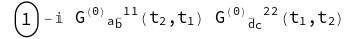

In [33]:
Framed[1,RoundingRadius->10]" "GGFFeynmanAmplitude[[1]]

In [197]:
For[u = 1, u <= 1, u++, If [GGFNambu[[u, 1, 1]] == 1 && GGFNambu[[u, 1, 2]] == 1 && GGFNambu[[u, 2, 1]] == 1 && GGFNambu[[u, 2, 2]] == 1 , Print["Framed[",u,",RoundingRadius->10]\" \"GGFFeynmanAmplitude[[",u,"]] \n"]]]

## <font color=#FA8072>Goldstone diagrams contributing to  $\boldsymbol{\Pi}_{acdb}^+$ (t > t')</font>

In [34]:
TimeClass = Table[0, {i, 1, 2}];
TimeClassOrdPlus = {{1, 2}};

### <font color=#E9967A>Assignment of the time indices, based on the time ordering</font>

It is convenient to assign the times (associated with the single-particle and the Nambu indices) only once the time ordering is established. This permits to evaluate the Gorkov-Green's functions more rapidly, exploiting the order of the natural numbers 1 and 2. The time indices appearing henceforth are, thus, relative times (= time-ordering dependent), whereas the absolute times (cf. the convention in the opening) correspond to the time classes. Times are sorted in ascending order: '2' is the latest time and '1' is the earliest one. 

In [36]:
T = 1;
For[r = 1, r <= 1, r++, 
   For[i = 1, i <= 2, i++, 
    For[j = 1, j <= 2, j++, 
     If[Abs[GGFSParticle[[r, i, j]]] == 2 || Abs[GGFSParticle[[r, i, j]]] == 3, GGFTime[[r, i, j]] = TimeClassOrdPlus[[T, 1]]]; (* Time Class 1 = t' *)
     If[Abs[GGFSParticle[[r, i, j]]] == 1 || Abs[GGFSParticle[[r, i, j]]] == 4, GGFTime[[r, i, j]] = TimeClassOrdPlus[[T, 2]]]; (*  Time Class 2 = t *)
    ]]];  

In [38]:
For[u = 1, u <= 1, u++, Print[u, "    ", GGFTime[[u]]]]

1    {{2, 1}, {1, 2}}


### <font color=#E9967A>Calculation of the amplitude associated to the Gorkov-Green's functions with alphabetic indices</font>

Initialization of the Gorkov-Green's functions based on the chosen time ordering. The polynomial, appearing as argument of a natural exponential, is also calculated, neglecting the imaginary unit $i$ (factor).

In [39]:
Clear[k];
GGFAmplitude = Table[0, {i, 1, 1}, {j, 1, 2}];
GGFPolynomial = Table[0.0, {i, 1, 1}, {j, 1, 2}];

For[r = 1, r <= 1, r++, 
  For[i = 1, i <= 2, i++,
   If[GGFTime[[r, i, 1]] > GGFTime[[r, i, 2]], 
    GGFAmplitude[[r, i]] = StringForm["``", Superscript[
        Superscript[Subscript[𝜒, NtL[GGFSParticle[[r, i, 1]]]], 
         GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", 
       Superscript[Superscript[Subscript[OverBar[𝜒], NtL[GGFSParticle[[r, i, 2]]]], 
         GGFNambu[[r, i, 2]]], Subscript[k, i]]];
    GGFPolynomial[[r,i]] = -(Subscript[Ω, Subscript[k, i]] - 
          Subscript[Ω, 0]) Subscript[t,GGFTime[[r, i, 1]]]/ℏ + ( 
        Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t,GGFTime[[r, i, 2]]]/ℏ;];
   If[GGFTime[[r, i, 1]] < GGFTime[[r, i, 2]], GGFAmplitude[[r,i]] = -StringForm["``", 
        Superscript[Superscript[Subscript[Υ, NtL[GGFSParticle[[r, i, 1]]]], 
          GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", Superscript[
        Superscript[Subscript[OverBar[Υ],NtL[GGFSParticle[[r, i, 2]]]], GGFNambu[[r, i, 2]]], 
        Subscript[k, i]]];
     GGFPolynomial[[r, i]] = +(Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
        GGFTime[[r, i, 1]]]/ℏ - (Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
        GGFTime[[r, i, 2]]]/ℏ;];
   If[GGFTime[[r, i, 1]] == GGFTime[[r, i, 2]], 
    If[GGFNambu[[r, i, 1]] == 2  &&  GGFNambu[[r, i, 2]] == 2, 
     GGFAmplitude[[r, i]] = -StringForm["``",Superscript[
          Superscript[Subscript[Υ, NtL[GGFSParticle[[r, i, 1]]]],
            GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", 
        Superscript[Superscript[Subscript[OverBar[Υ],NtL[GGFSParticle[[r, i, 2]]]], GGFNambu[[r, i, 2]]], 
         Subscript[k, i]]];
      GGFPolynomial[[r,i]] = +(Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
         GGFTime[[r, i, 1]]]/ℏ- (Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t,
         GGFTime[[r, i, 2]]]/ℏ, 
     GGFAmplitude[[r, i]] = StringForm["``", Superscript[
         Superscript[Subscript[𝜒, NtL[GGFSParticle[[r, i, 1]]]], 
          GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", Superscript[
         Superscript[Subscript[OverBar[𝜒], NtL[GGFSParticle[[r, i, 2]]]], 
          GGFNambu[[r, i, 2]]], Subscript[k, i]]];
     GGFPolynomial[[r, i]] = -(Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
         GGFTime[[r, i, 1]]]/ℏ + (Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
         GGFTime[[r, i, 2]]]/ℏ]];
   ]];

<html>The integration over (t-t') is performed, solving a linear equation, obtained by equating the coefficient of (t-t') in the total polynomial to zero. In this special case, the frequency &#989; is multiplied by the same time interval as $\omega$.</html>  

In [43]:
GGFTotalPolynomial = Table[0, {r, 1, 1}];

For[r = 1, r <= 1, r++,
  For[j = 1, j <= 2, j++,
   GGFTotalPolynomial[[r]] = 
     GGFTotalPolynomial[[r]] + GGFPolynomial[[r, j]];
   ];
  If[(TimeClassOrdPlus[[T, 2]] == 2 && 
      TimeClassOrdPlus[[T, 1]] == 1) || (TimeClassOrdPlus[[T, 2]] == 
       1 && TimeClassOrdPlus[[T, 1]] == 2),
   GGFTotalPolynomial[[r]] = 
    GGFTotalPolynomial[[
      r]] + 𝜔 (Subscript[t, TimeClassOrdPlus[[T, 2]]] - 
        Subscript[t, 
        TimeClassOrdPlus[[T, 1]]]) - ϝ(Subscript[t, 2] - 
        Subscript[t, 1])];
  ];

In [45]:
GGFGoldstoneAmplitude = Table[1, {i, 1, 1}];
Clear[ϝ];
Clear[k];

In [48]:
For[r = 1, r <= 1, r++,
  Symb = StringForm["``", Subscript["∑",Subscript[​,Subscript[k,1] Subscript[k,2]]]];
    Pref = Power[(-1), AmplSign[[r]]] Power[(-I),1] Power[(-I),-1] GGFMult[[r]]/1;
  TimeIntegralSolutions = 
   Solve[Coefficient[GGFTotalPolynomial[[r]], Subscript[t, 
      TimeClassOrdPlus[[T, 1]]]] == 0, {ϝ}];
  {ϝ} = TimeIntegralSolutions // Values // Flatten;
  GGFGoldstoneAmplitude[[r]] = StringForm["`1``2`",Symb,Pref GGFAmplitude[[r, 2]] GGFAmplitude[[r, 1]]/(ϝ + I Superscript[η,"(0)"])];
  Clear[ϝ];
  Clear[TimeIntegralSolutions];
  ];

### <font color=#FFA500> Results with T = 1, corresponding to {1,2}</font>

In [49]:
For[u = 1, u <= 1, u++, Print["Framed[",u,",RoundingRadius->10]\" \"GGFGoldstoneAmplitude[[",u,"]]"]]

Framed[1,RoundingRadius->10]" "GGFGoldstoneAmplitude[[1]]


k     k     k     k
                                               1 1   2 2 _ 1 1 _ 2 2
                                             𝜒     Υ     𝜒     Υ
                                              a     _     _     c
                                                    d     b
  Framed[1, RoundingRadius -> 10] ∑      -------------------------------
                                   ​     𝜔 ℏ + 2 Ω  - Ω   - Ω
                                    k  k          0    k     k
                                     1  2               1     2      (0)
                                         ---------------------- + I η
                                                   ℏ
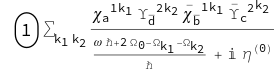

In [50]:
Framed[1,RoundingRadius->10]" "GGFGoldstoneAmplitude[[1]]

## <font color=#FA8072>Goldstone diagrams contributing to  $\boldsymbol{\Pi}_{acdb}^-$ (t < t')</font>

In [51]:
TimeClass = Table[0, {i, 1, 2}];
TimeClassOrdMinus = {{2, 1}};

### <font color=#E9967A>Assignment of the time indices, based on the time ordering</font>

It is convenient to assign the times (associated with the single-particle and the Nambu indices) only once the time ordering is established. This permits to evaluate the Gorkov-Green's functions more rapidly, exploiting the order of the natural numbers 1 and 2. The time indices appearing henceforth are, thus, relative times (= time-ordering dependent), whereas the absolute times (cf. the convention in the opening) correspond to the time classes. Times are sorted in ascending order: '2' is the latest time and '1' is the earliest one. 

In [53]:
T = 1;
For[r = 1, r <= 1, r++, 
   For[i = 1, i <= 2, i++, 
    For[j = 1, j <= 2, j++, 
     If[Abs[GGFSParticle[[r, i, j]]] == 2 || Abs[GGFSParticle[[r, i, j]]] == 3, GGFTime[[r, i, j]] = TimeClassOrdMinus[[T, 1]]]; (* Time Class 1 = t' *)
     If[Abs[GGFSParticle[[r, i, j]]] == 1 || Abs[GGFSParticle[[r, i, j]]] == 4, GGFTime[[r, i, j]] = TimeClassOrdMinus[[T, 2]]]; (*  Time Class 2 = t *)
    ]]];  

In [55]:
For[u = 1, u <= 1, u++, Print[u, "    ", GGFTime[[u]]]]

1    {{1, 2}, {2, 1}}


### <font color=#E9967A>Calculation of the amplitude associated to the Gorkov-Green's functions with alphabetic indices</font>

Initialization of the Gorkov-Green's functions based on the chosen time ordering. The polynomial, appearing as argument of a natural exponential, is also calculated, neglecting the imaginary unit $i$ (factor).

In [56]:
Clear[k];
GGFAmplitude = Table[0, {i, 1, 1}, {j, 1, 2}];
GGFPolynomial = Table[0.0, {i, 1, 1}, {j, 1, 2}];

For[r = 1, r <= 1, r++, 
  For[i = 1, i <= 2, i++,
   If[GGFTime[[r, i, 1]] > GGFTime[[r, i, 2]], 
    GGFAmplitude[[r, i]] = StringForm["``", Superscript[
        Superscript[Subscript[𝜒, NtL[GGFSParticle[[r, i, 1]]]], 
         GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", 
       Superscript[Superscript[Subscript[OverBar[𝜒], NtL[GGFSParticle[[r, i, 2]]]], 
         GGFNambu[[r, i, 2]]], Subscript[k, i]]];
    GGFPolynomial[[r,i]] = -(Subscript[Ω, Subscript[k, i]] - 
          Subscript[Ω, 0]) Subscript[t,GGFTime[[r, i, 1]]]/ℏ + ( 
        Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t,GGFTime[[r, i, 2]]]/ℏ;];
   If[GGFTime[[r, i, 1]] < GGFTime[[r, i, 2]], GGFAmplitude[[r,i]] = -StringForm["``", 
        Superscript[Superscript[Subscript[Υ, NtL[GGFSParticle[[r, i, 1]]]], 
          GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", Superscript[
        Superscript[Subscript[OverBar[Υ],NtL[GGFSParticle[[r, i, 2]]]], GGFNambu[[r, i, 2]]], 
        Subscript[k, i]]];
     GGFPolynomial[[r, i]] = +(Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
        GGFTime[[r, i, 1]]]/ℏ - (Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
        GGFTime[[r, i, 2]]]/ℏ;];
   If[GGFTime[[r, i, 1]] == GGFTime[[r, i, 2]], 
    If[GGFNambu[[r, i, 1]] == 2  &&  GGFNambu[[r, i, 2]] == 2, 
     GGFAmplitude[[r, i]] = -StringForm["``",Superscript[
          Superscript[Subscript[Υ, NtL[GGFSParticle[[r, i, 1]]]],
            GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", 
        Superscript[Superscript[Subscript[OverBar[Υ],NtL[GGFSParticle[[r, i, 2]]]], GGFNambu[[r, i, 2]]], 
         Subscript[k, i]]];
      GGFPolynomial[[r,i]] = +(Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
         GGFTime[[r, i, 1]]]/ℏ- (Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t,
         GGFTime[[r, i, 2]]]/ℏ, 
     GGFAmplitude[[r, i]] = StringForm["``", Superscript[
         Superscript[Subscript[𝜒, NtL[GGFSParticle[[r, i, 1]]]], 
          GGFNambu[[r, i, 1]]], Subscript[k, i]]] StringForm["``", Superscript[
         Superscript[Subscript[OverBar[𝜒], NtL[GGFSParticle[[r, i, 2]]]], 
          GGFNambu[[r, i, 2]]], Subscript[k, i]]];
     GGFPolynomial[[r, i]] = -(Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
         GGFTime[[r, i, 1]]]/ℏ + (Subscript[Ω, Subscript[k, i]] - Subscript[Ω, 0]) Subscript[t, 
         GGFTime[[r, i, 2]]]/ℏ]];
   ]];

<html>The integration over (t-t') is performed, solving a linear equation, obtained by equating the coefficient of (t-t') in the total polynomial to zero. In this special case, the frequency &#989; is multiplied by the same time interval as $\omega$.</html>  

In [60]:
GGFTotalPolynomial = Table[0, {r, 1, 1}];

For[r = 1, r <= 1, r++,
  For[j = 1, j <= 2, j++,
   GGFTotalPolynomial[[r]] = 
     GGFTotalPolynomial[[r]] + GGFPolynomial[[r, j]];
   ];
  If[(TimeClassOrdMinus[[T, 2]] == 2 && 
      TimeClassOrdMinus[[T, 1]] == 1) || (TimeClassOrdMinus[[T, 2]] == 
       1 && TimeClassOrdMinus[[T, 1]] == 2),
   GGFTotalPolynomial[[r]] = 
    GGFTotalPolynomial[[
      r]] + 𝜔 (Subscript[t, TimeClassOrdMinus[[T, 2]]] - 
        Subscript[t, 
        TimeClassOrdMinus[[T, 1]]]) - ϝ(Subscript[t, 2] - 
        Subscript[t, 1])];
  ];

In [62]:
GGFGoldstoneAmplitude = Table[1, {i, 1, 1}];
Clear[ϝ];
Clear[k];

In [65]:
For[r = 1, r <= 1, r++,
  Symb = StringForm["``", Subscript["∑",Subscript[​,Subscript[k,1] Subscript[k,2]]]];
    Pref = Power[(-1), AmplSign[[r]]] Power[(-I),1] Power[(-I),-1] GGFMult[[r]]/1;
  TimeIntegralSolutions = 
   Solve[Coefficient[GGFTotalPolynomial[[r]], Subscript[t, 
      TimeClassOrdMinus[[T, 1]]]] == 0, {ϝ}];
  {ϝ} = TimeIntegralSolutions // Values // Flatten;
  GGFGoldstoneAmplitude[[r]] = StringForm["`1``2`",Symb,Pref GGFAmplitude[[r, 2]] GGFAmplitude[[r, 1]]/(ϝ + I Superscript[η,"(0)"])];
  Clear[ϝ];
  Clear[TimeIntegralSolutions];
  ];

### <font color=#FFA500> Results with T = 1, corresponding to {2,1}</font>

In [66]:
For[u = 1, u <= 1, u++, Print["Framed[",u,",RoundingRadius->10]\" \"GGFGoldstoneAmplitude[[",u,"]]"]]

Framed[1,RoundingRadius->10]" "GGFGoldstoneAmplitude[[1]]


k     k     k     k
                                                2 2   1 1 _ 2 2 _ 1 1
                                              𝜒     Υ     𝜒     Υ
                                               _     a     c     _
                                               d                 b
  Framed[1, RoundingRadius -> 10] ∑      ----------------------------------
                                   ​     -(𝜔 ℏ) + 2 Ω  - Ω   - Ω
                                    k  k             0    k     k
                                     1  2                  1     2      (0)
                                         ------------------------- + I η
                                                     ℏ
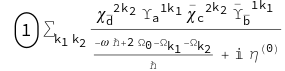

In [67]:
Framed[1,RoundingRadius->10]" "GGFGoldstoneAmplitude[[1]]